In [1]:
import os
import datetime
import numpy as np
import pandas as pd
from functools import partial

# Model
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analytics
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.seasonal import STL
from prophet import Prophet

# Optimization
import optuna

# Evaluation
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

e:\05 Code Projects\clear-stocks\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
Ticker = ['AAPL', 'GOOG', 'MSFT']

# Data Loading

In [3]:
# load apple inc stock data
aapl_stock = pd.read_csv('../data/aapl_stock_price.csv', index_col=[0], parse_dates=[0])

# load google stock data
goog_stock = pd.read_csv('../data/goog_stock_price.csv', index_col=[0], parse_dates=[0])

# load microsoft stock data
msft_stock = pd.read_csv('../data/msft_stock_price.csv', index_col=[0], parse_dates=[0])

# EDA

## Plot Function

In [4]:
def dickeyFuller_plot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
        
    with plt.style.context(style):    
        _ = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

def seasonalDecompose(y, period, is_plot=True):
    stl = STL(y, period=period)  # Mulai dengan dugaan
    result = stl.fit()
    if is_plot:
        fig = result.plot() 
        fig.set_size_inches(13, 6)
        for axes in fig.axes:
            axes.grid(True)
        plt.show()
    return result

def lineplot(data, ticker):
    _, axes = plt.subplots(2, 1, figsize=(15, 7))

    axes[0].plot(data.index, data['Close'])
    axes[0].plot(data.index, data['Open'])
    axes[0].plot(data.index, data['High'])
    axes[0].plot(data.index, data["Close"])
    # axes[0].legend(data.columns)
    axes[0].grid("True")

    axes[1].plot(data.index, data['Volume'])
    # axes[1].legend(data.columns)
    axes[1].grid("True")

    plt.suptitle(ticker + " Stock Price", y=0.95, fontsize=18)

## aapl_stock EDA

In [5]:
aapl_stock['Close'].name

'Close'

In [6]:
aapl_stock.describe()

,Close,High,Low,Open,Volume
count,2528.000000,2528.000000,2528.000000,2528.000000,2.528000e+03
mean,94.959042,95.884235,93.936092,94.879582,1.167576e+08
std,66.308680,66.917162,65.617952,66.245605,6.840965e+07
min,20.697264,21.001965,20.497944,20.619362,2.294595e+07
25%,35.598132,35.891135,35.059612,35.518434,7.060312e+07
50%,65.153210,65.857531,64.379692,65.015915,9.975325e+07
75%,151.601234,153.284429,149.614227,151.346519,1.425081e+08
max,259.019989,260.100006,257.630005,258.190002,6.488252e+08


In [7]:
aapl_stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2528 entries, 2015-01-02 to 2025-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2528 non-null   float64
 1   High    2528 non-null   float64
 2   Low     2528 non-null   float64
 3   Open    2528 non-null   float64
 4   Volume  2528 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 118.5 KB


In [8]:
aapl_stock

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.347174,24.817059,23.906238,24.805924,212818400
2015-01-05,23.661276,24.195743,23.474213,24.115573,257142000
2015-01-06,23.663504,23.924056,23.300511,23.725858,263188400
2015-01-07,23.995319,24.095531,23.761490,23.872837,160423600
2015-01-08,24.917274,24.975175,24.206879,24.324908,237458000
...,...,...,...,...,...
2025-01-14,233.279999,236.119995,232.470001,234.750000,39435300
2025-01-15,237.869995,238.960007,234.429993,234.639999,39832000
2025-01-16,228.259995,238.009995,228.029999,237.350006,71759100


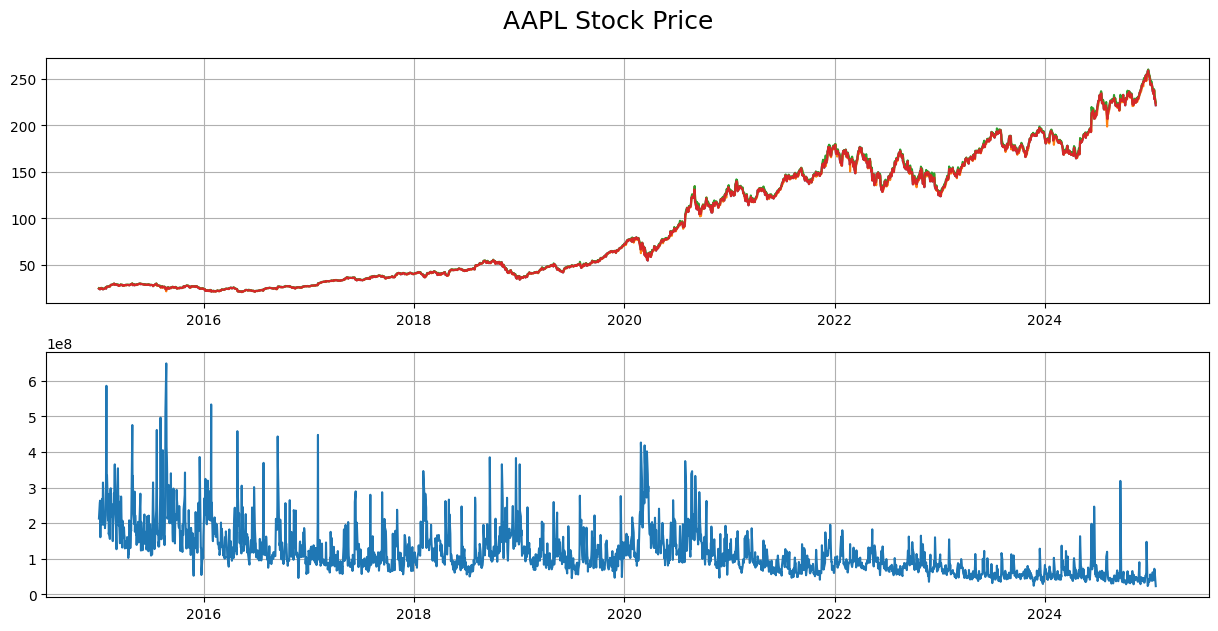

In [9]:
lineplot(aapl_stock, Ticker[0])

### Is there any strong trend or seasonal component in AAPL stock?

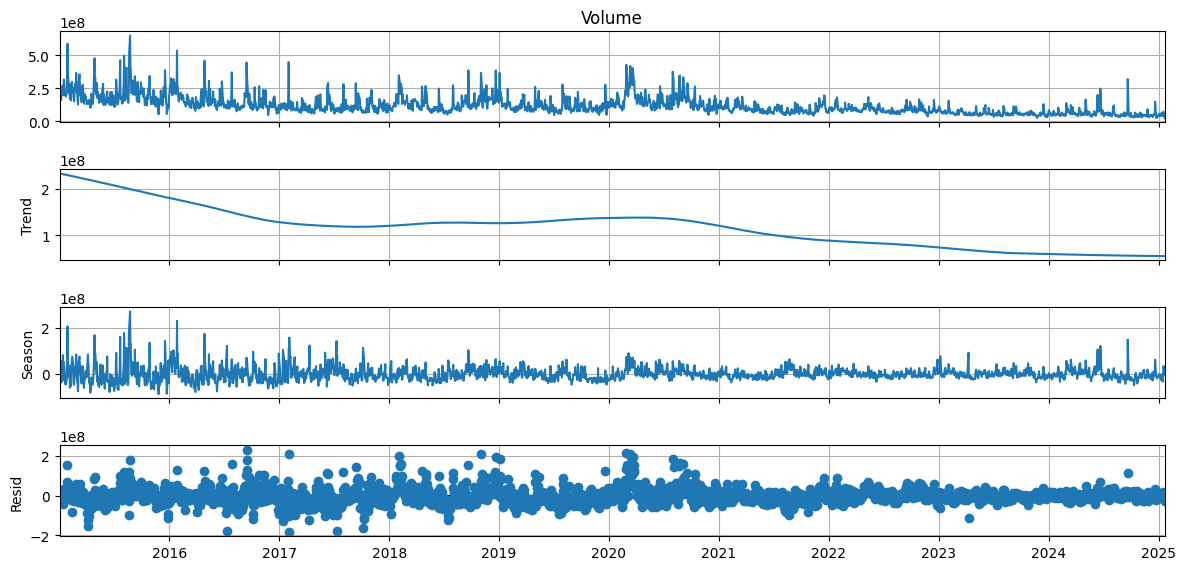

In [10]:
# Volume Stock Visualization with 365 period
seasonalDecompose(aapl_stock['Volume'], period=365)

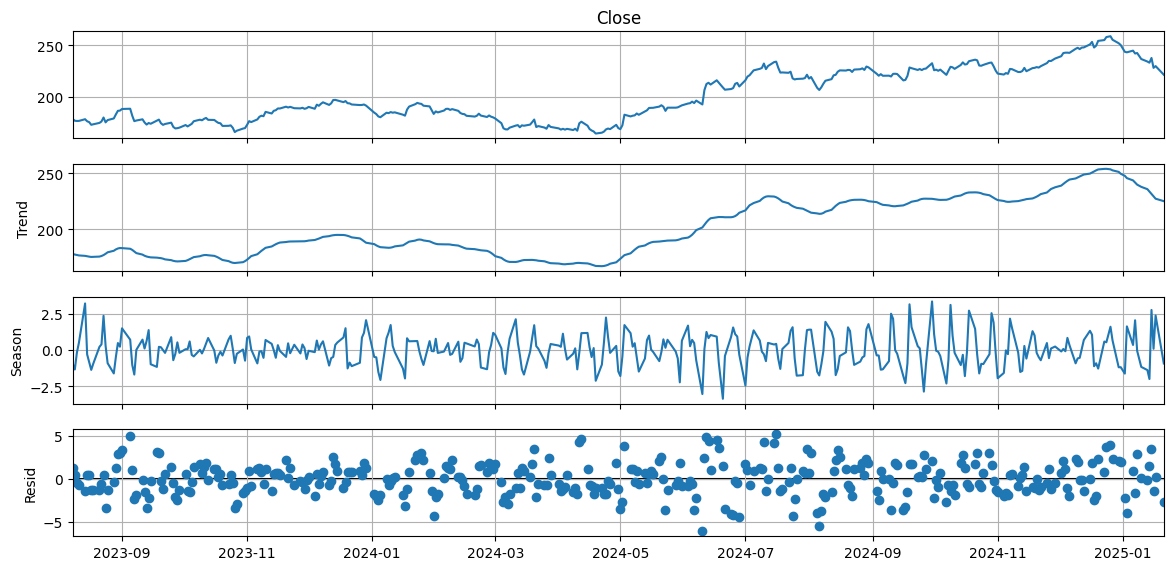

In [18]:
# Close price Visualization with 365 period
seasonalDecompose(aapl_stock['Close'][-365:], period=7)

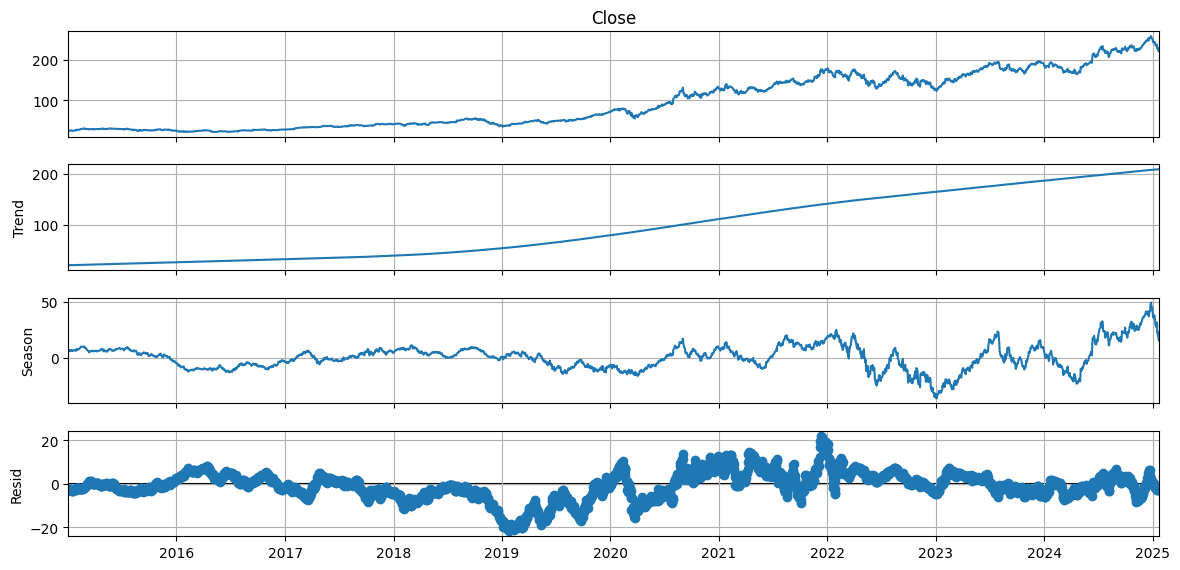

In [12]:
# Close price Visualization with 365 period
close_aapl_SDecompose = seasonalDecompose(aapl_stock['Close'], period=730)

From seasonal decompose plot with Apple.inc stock data, it can conclude that:
- Stock price have a linear rising trend in 2 year period
- Using ARIMA model would challenging, because there's no strong seasonal component in this stock data.
- Other model like traditional machine learning or sequencial deep learning model would be better 

## goog stock EDA

In [13]:
goog_stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2528 entries, 2015-01-02 to 2025-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2528 non-null   float64
 1   High    2528 non-null   float64
 2   Low     2528 non-null   float64
 3   Open    2528 non-null   float64
 4   Volume  2528 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 118.5 KB


In [14]:
goog_stock.describe()

,Close,High,Low,Open,Volume
count,2528.000000,2528.000000,2528.000000,2528.000000,2.528000e+03
mean,83.049639,83.891984,82.179659,82.998665,3.070099e+07
std,44.997725,45.489549,44.524035,44.978371,1.537232e+07
min,24.472139,24.642359,24.224213,24.576479,4.642769e+06
25%,46.351086,46.627515,46.032862,46.362418,2.112105e+07
50%,64.780731,65.270596,64.431237,64.746857,2.689695e+07
75%,121.600578,122.794784,120.025174,121.349853,3.564358e+07
max,200.520004,203.839996,199.703003,200.509995,2.232980e+08


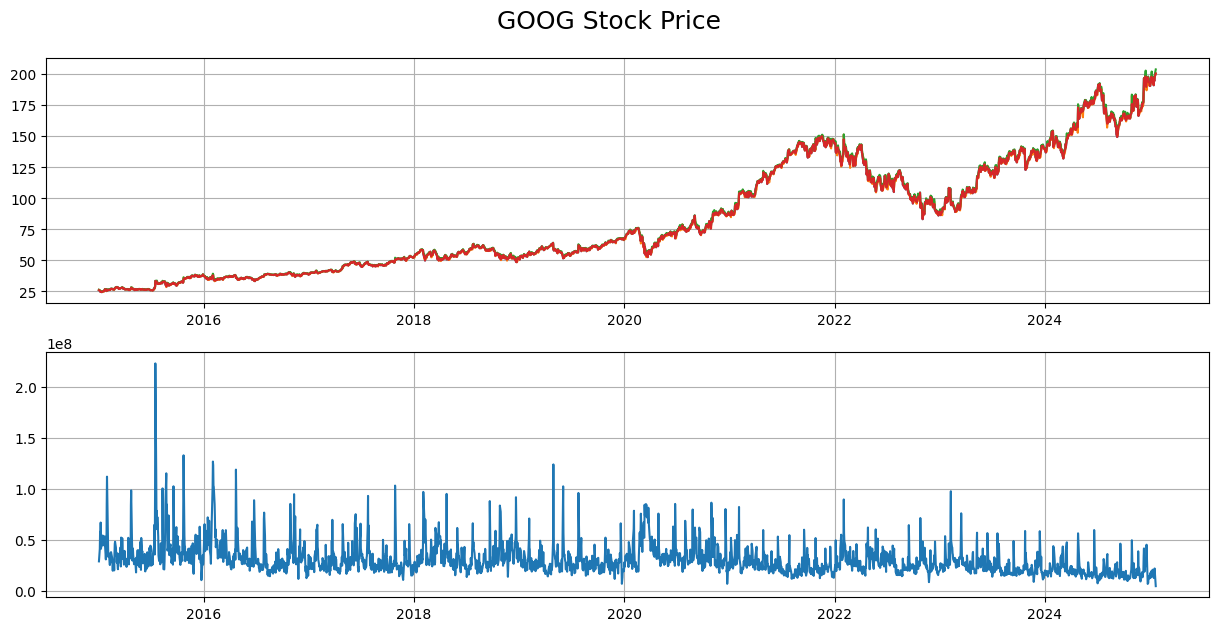

In [15]:
lineplot(goog_stock, Ticker[1])

### Is there any strong trend or seasonal component in google stock?

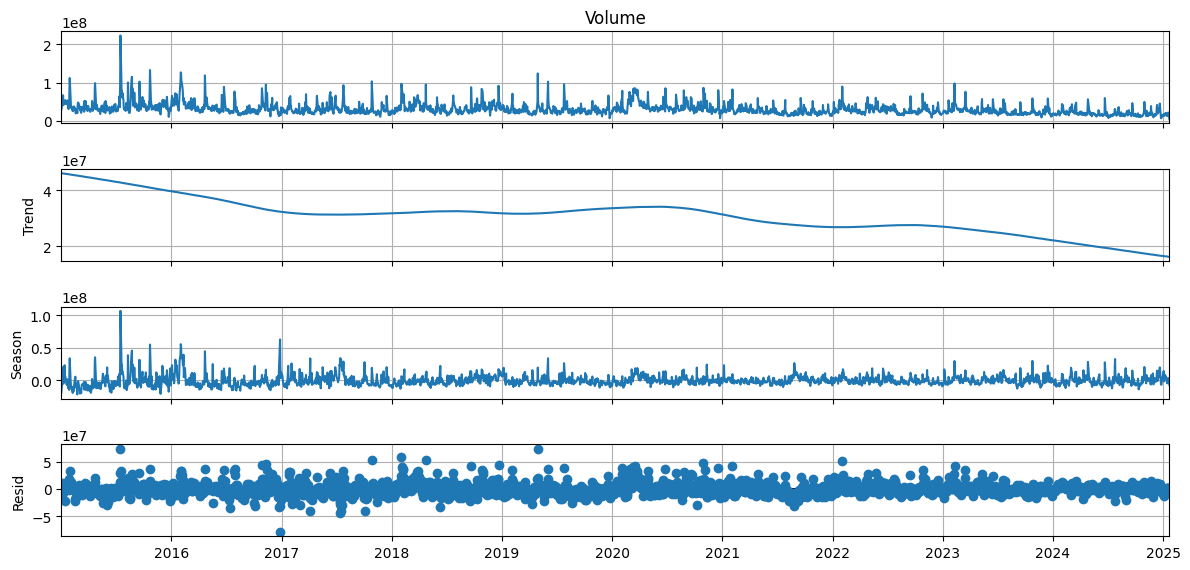

In [16]:
seasonalDecompose(goog_stock['Volume'], period=365)

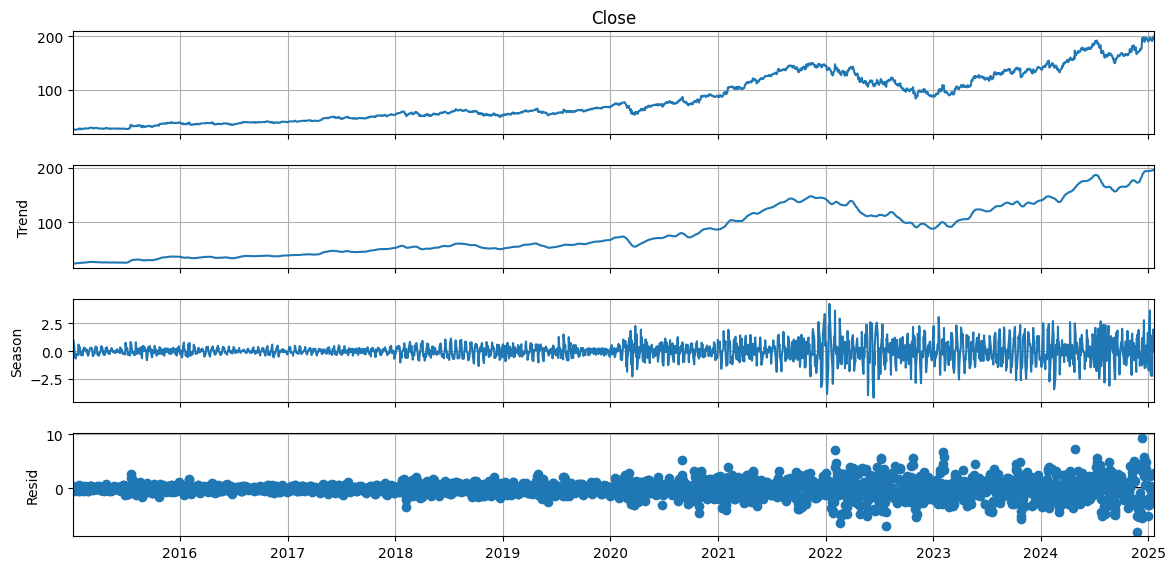

In [17]:
seasonalDecompose(goog_stock["Close"], period=12)

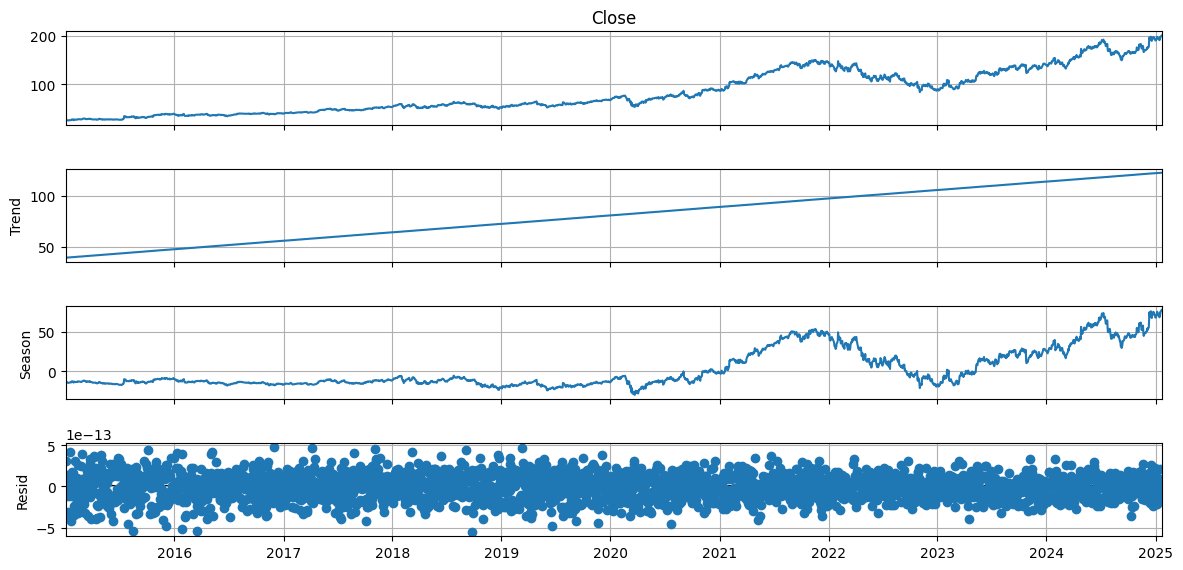

In [18]:
seasonalDecompose(goog_stock["Close"], period=365*6)

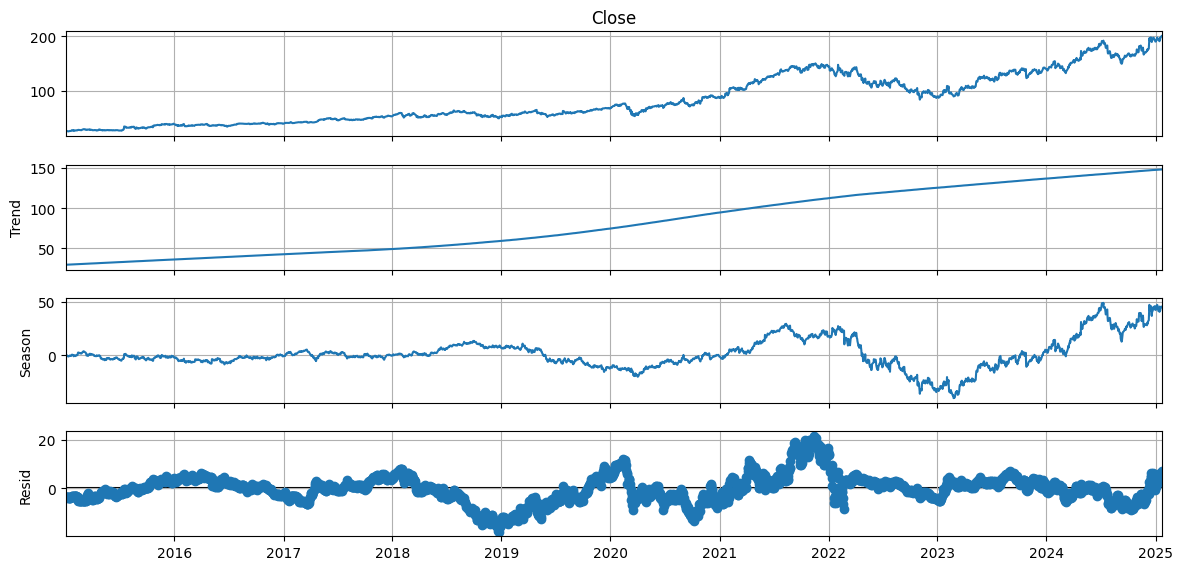

In [19]:
seasonalDecompose(goog_stock["Close"], period=730)

The result that we can get from seasonal decompose visualization is the same with aapl stock

## msft stock EDA

In [20]:
msft_stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2528 entries, 2015-01-02 to 2025-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2528 non-null   float64
 1   High    2528 non-null   float64
 2   Low     2528 non-null   float64
 3   Open    2528 non-null   float64
 4   Volume  2528 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 118.5 KB


In [21]:
msft_stock.describe()

,Close,High,Low,Open,Volume
count,2528.000000,2528.000000,2528.000000,2528.000000,2.528000e+03
mean,183.151587,184.851314,181.287197,183.117080,2.882430e+07
std,124.677232,125.763415,123.499194,124.692400,1.335918e+07
min,34.691196,35.232123,34.545212,34.854342,4.237157e+06
25%,65.723301,66.087777,65.196006,65.640751,2.055610e+07
50%,148.835869,150.876032,145.874004,147.020385,2.568980e+07
75%,278.231865,281.380592,274.802307,278.348294,3.312338e+07
max,465.786438,466.573450,462.698189,465.228569,1.691640e+08


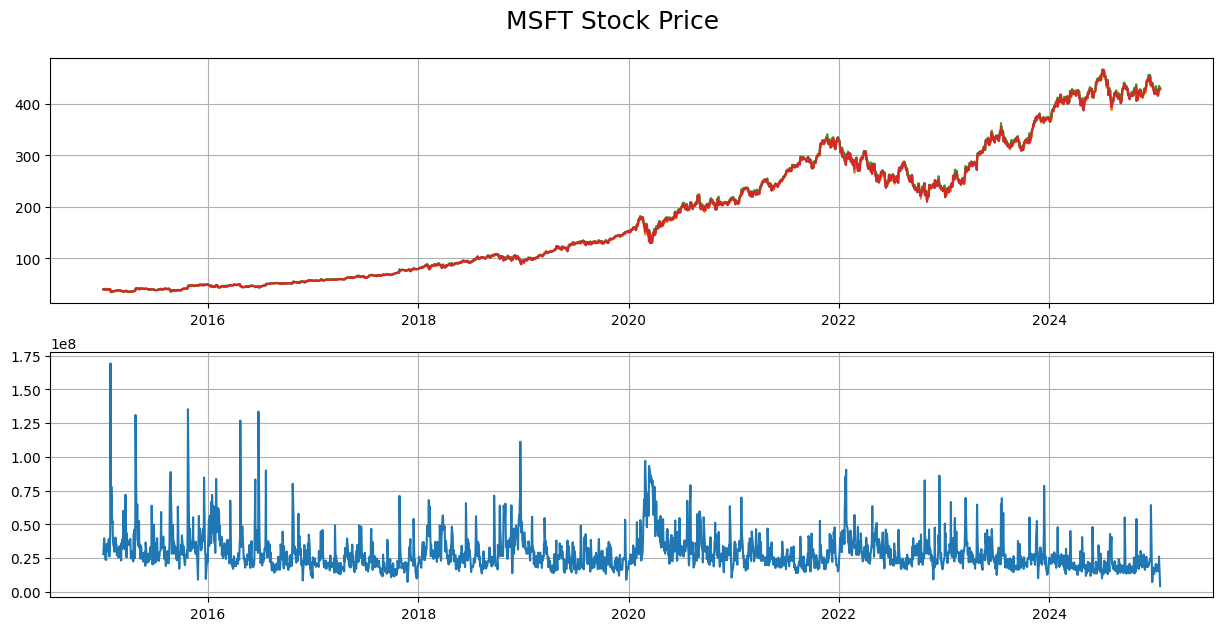

In [22]:
lineplot(msft_stock, Ticker[2])

### Is there any strong trend or seasonal component in Microsoft stock?

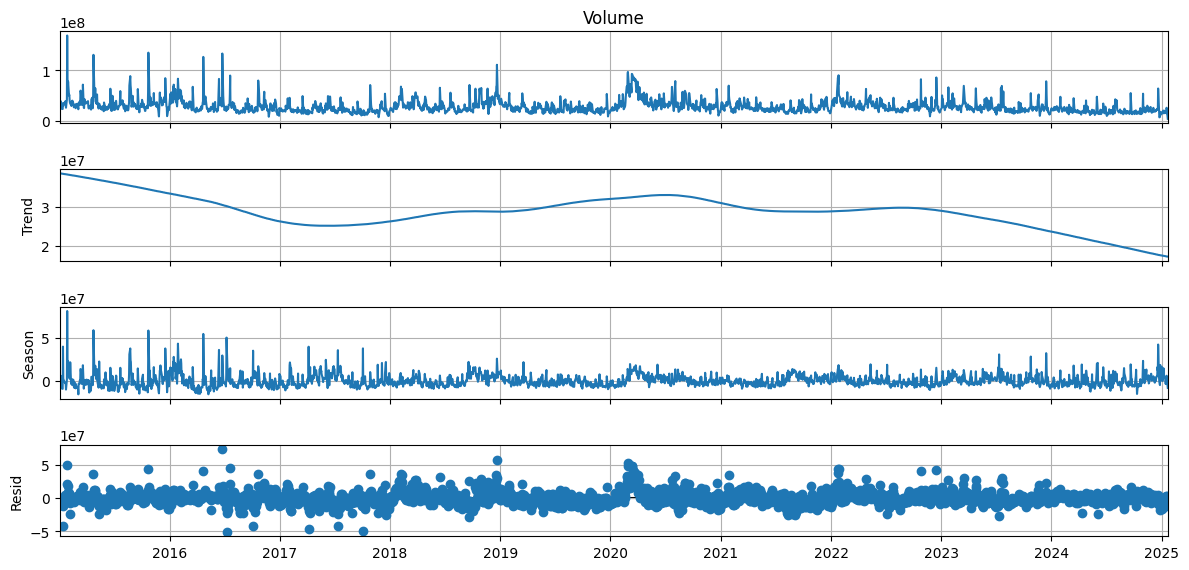

In [23]:
seasonalDecompose(msft_stock['Volume'], period=365)

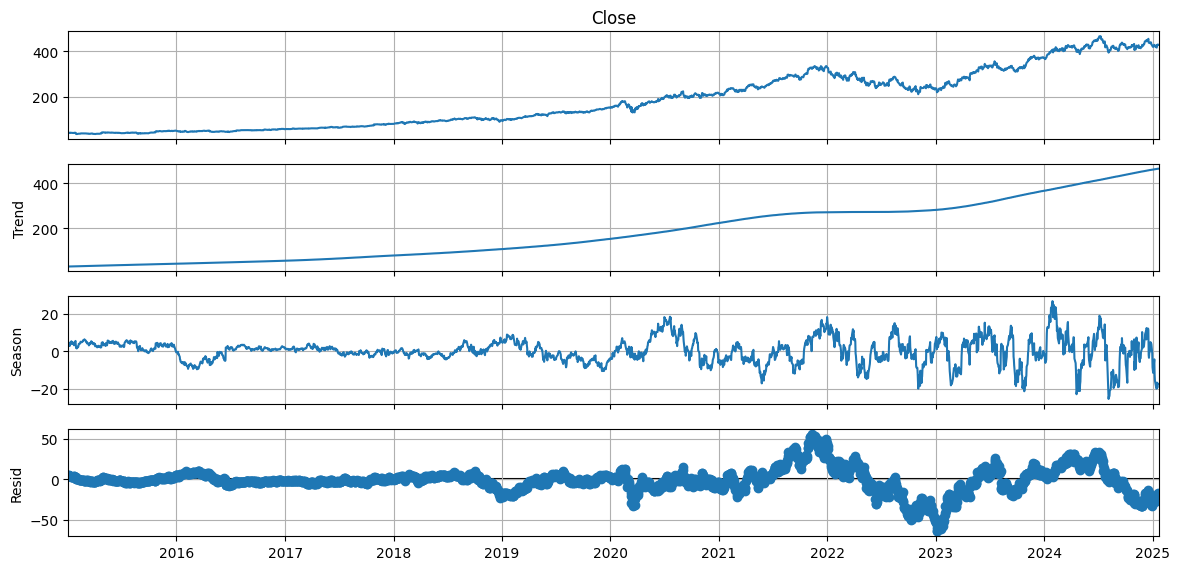

In [24]:
seasonalDecompose(msft_stock["Close"], period=365)

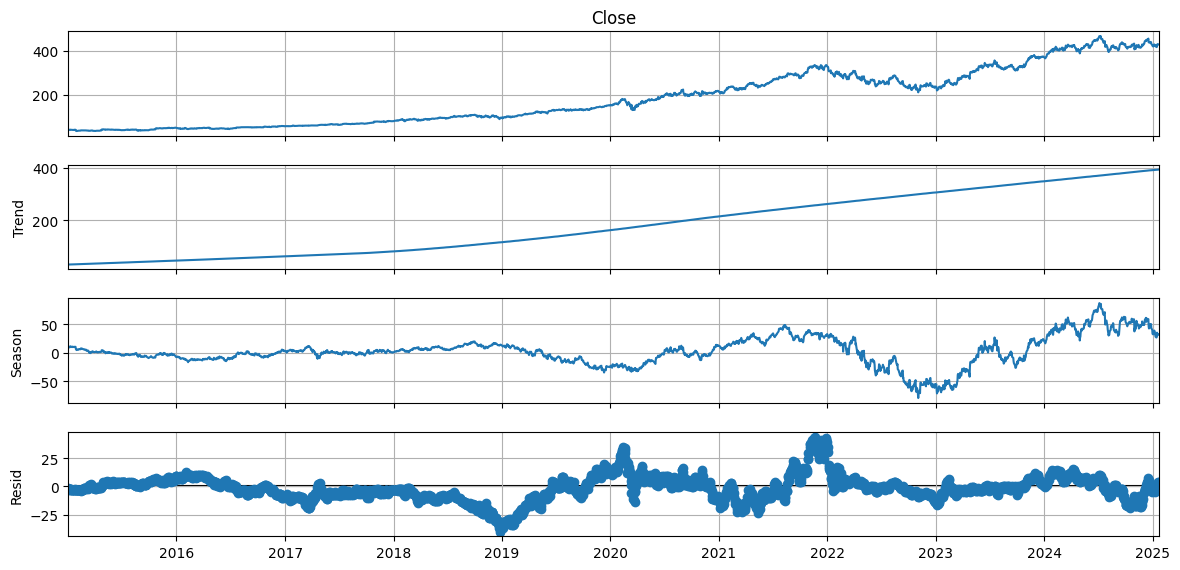

In [25]:
seasonalDecompose(msft_stock["Close"], period=730)

The result that we can get from seasonal decompose visualization is the same with aapl stock

# Data Preparation

In [67]:
def feature_engineering(data, label=None):
    """
    Creates time series features
    """
    sdcompose_result = seasonalDecompose(data, period=730, is_plot=False)
    df = pd.concat(
        [data, 
         sdcompose_result.trend,
         sdcompose_result.seasonal,
         sdcompose_result.resid
        ], axis=1)
    df['lag'] = df[df.columns[0]].diff()
    df['ma'] = df[df.columns[0]].rolling(window=2).mean()
    df = df.fillna(0)
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    
    X = df[[col for col in df.columns if (col != label) & (col != 'date')]]
    if label:
        y = df[label]
        return X, y
    return X

In [65]:
def train_test_split(data, split_date):
    train = data[data.index < split_date]
    test = data[data.index >= split_date]
    return train, test

In [135]:
# Define split date
start_date = aapl_stock.index[0]
split_index = round(len(aapl_stock) * 0.8)
split_date = aapl_stock.index[split_index] 

# First we use the aapl close stock price + volume
aapl_close_train, aapl_close_test = train_test_split(aapl_stock["Close"], split_date)
aapl_vol_train, aapl_vol_test = train_test_split(aapl_stock["Volume"], split_date)

# Perform feature engineering & split into X y
X_close_train, y_close_train = feature_engineering(aapl_close_train, "Close")
X_close_test, y_close_test = feature_engineering(aapl_close_test, "Close")

X_vol_train, y_vol_train = feature_engineering(aapl_vol_train, "Volume")
X_vol_test, y_vol_test = feature_engineering(aapl_vol_test, "Volume")

# Modelling

In [136]:
# Using MLflow

In [137]:
def train_eval_ml_model(model, X_train, X_test, y_train, y_test):
    """
    
    """
    # Train the input
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Eval
    rmse = root_mean_squared_error(y_test, y_pred)
    return rmse

def optuna_search(objective, n_trials, direction):
    """
    
    """
    # Create study
    study = optuna.create_study(direction=direction)
    study.optimize(objective, n_trials=n_trials)

    # Display the best trial, value, and params
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    return trial.params

def xgb_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 100, 350)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.1)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 10.0)
    reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-5, 10.0)
    
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        random_state=42,
        objective='reg:squarederror'
    )
    
    rmse = train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

def rf_objective(trial, X_train, X_test, y_train, y_test):
    """
    
    """
    n_estimators = trial.suggest_int('n_estimators', 100, 350)
    max_depth = trial.suggest_int('max_depth', 10, 32)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        bootstrap=bootstrap
    )
    
    rmse =train_eval_ml_model(model, X_train, X_test, y_train, y_test)
    
    return rmse

## ARIMA

## Traditional ML

### Close Price

In [138]:
# Hyperparameter tuning with xgboost
xgb_partial = partial(xgb_objective, X_train=X_close_train, X_test=X_close_test, y_train=y_close_train, y_test=y_close_test)
xgb_best_params = optuna_search(xgb_partial, 100, "minimize")

[I 2025-01-22 02:13:01,446] A new study created in memory with name: no-name-3a114bdb-fde7-4cdd-9cbd-cc5a3610958d
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:37: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.1)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:41: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 10.0)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:42: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optun

Best trial:
  Value: 31.657942829385842
  Params: 
    n_estimators: 254
    max_depth: 7
    learning_rate: 0.04047698043535623
    min_child_weight: 4
    subsample: 0.9479803073442358
    colsample_bytree: 0.9966477617736953
    reg_alpha: 0.001308738224844944
    reg_lambda: 0.002402267205240915


In [139]:
# Hyperparameter tuning with random forest
rf_partial = partial(rf_objective, X_train=X_close_train, X_test=X_close_test, y_train=y_close_train, y_test=y_close_test)
rf_best_params = optuna_search(rf_partial, 100, "minimize")

[I 2025-01-22 02:13:31,018] A new study created in memory with name: no-name-29b21d89-e3a2-4f07-9d33-ea63fb2328fc
[I 2025-01-22 02:13:33,571] Trial 0 finished with value: 30.323376315648964 and parameters: {'n_estimators': 229, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 5, 'bootstrap': False}. Best is trial 0 with value: 30.323376315648964.
[I 2025-01-22 02:13:36,659] Trial 1 finished with value: 30.366554267018206 and parameters: {'n_estimators': 307, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 0 with value: 30.323376315648964.
[I 2025-01-22 02:13:38,506] Trial 2 finished with value: 30.350654844850798 and parameters: {'n_estimators': 181, 'max_depth': 22, 'min_samples_split': 18, 'min_samples_leaf': 5, 'bootstrap': False}. Best is trial 0 with value: 30.323376315648964.
[I 2025-01-22 02:13:41,239] Trial 3 finished with value: 29.779643132830532 and parameters: {'n_estimators': 224, 'max_depth': 15, 'min_samples_

Best trial:
  Value: 29.671340841826
  Params: 
    n_estimators: 347
    max_depth: 20
    min_samples_split: 2
    min_samples_leaf: 1
    bootstrap: False


In [140]:
rf_model = RandomForestRegressor(**rf_best_params)
rf_model.fit(X_close_train, y_close_train)
close_predict = rf_model.predict(X_close_test)
rmse = root_mean_squared_error(y_close_test, close_predict)
mae = mean_absolute_error(y_close_test, close_predict)
mape = mean_absolute_percentage_error(y_close_test, close_predict)

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 29.71723995428592 | MAE : 19.740834420805285, | MAPE : 0.09044538522831386


In [141]:
close_predict_series = pd.Series(close_predict, index=aapl_close_test.index, name="Predict")
aapl_close_test = pd.concat([aapl_close_test, close_predict_series], axis=1)
close_all = pd.concat([aapl_close_train, aapl_close_test], sort=False)

In [142]:
close_all

,Close,Predict
Date,,
2015-01-02,24.347174,NaN
2015-01-05,23.661276,NaN
2015-01-06,23.663504,NaN
2015-01-07,23.995319,NaN
2015-01-08,24.917274,NaN
...,...,...
2025-01-14,233.279999,177.718914
2025-01-15,237.869995,177.718999
2025-01-16,228.259995,177.735389


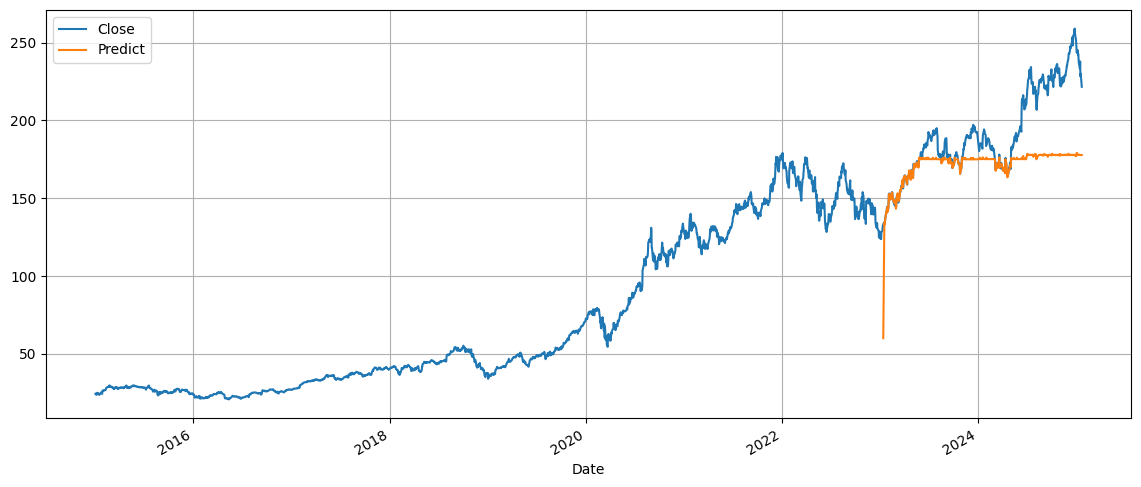

In [143]:
close_all[['Close', 'Predict']].plot(figsize=(14,6))
plt.grid(True)

### Volume Selling

In [144]:
# Hyperparameter tuning with xgboost
xgb_partial = partial(xgb_objective, X_train=X_vol_train, X_test=X_vol_test, y_train=y_vol_train, y_test=y_vol_test)
xgb_best_params = optuna_search(xgb_partial, 100, "minimize")

[I 2025-01-22 02:19:10,788] A new study created in memory with name: no-name-6205fd89-c332-4046-b83b-a463275a6dd4
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:37: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 0.001, 0.1)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:41: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-5, 10.0)
C:\Users\fadhil\AppData\Local\Temp\ipykernel_31540\1313802648.py:42: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optun

Best trial:
  Value: 10617740.11221969
  Params: 
    n_estimators: 154
    max_depth: 6
    learning_rate: 0.059955661993474026
    min_child_weight: 3
    subsample: 0.6351787360113536
    colsample_bytree: 0.9999881093911923
    reg_alpha: 0.005506501175775249
    reg_lambda: 1.5285498738507097e-05


In [145]:
# Hyperparameter tuning with random forest
rf_partial = partial(rf_objective, X_train=X_vol_train, X_test=X_vol_test, y_train=y_vol_train, y_test=y_vol_test)
rf_best_params = optuna_search(rf_partial, 100, "minimize")

[I 2025-01-22 02:19:36,116] A new study created in memory with name: no-name-428d49e6-a3d7-4bf8-9951-76ce01fb6a99
[I 2025-01-22 02:19:39,303] Trial 0 finished with value: 12702694.276887678 and parameters: {'n_estimators': 286, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 6, 'bootstrap': False}. Best is trial 0 with value: 12702694.276887678.
[I 2025-01-22 02:19:40,784] Trial 1 finished with value: 12437051.284783326 and parameters: {'n_estimators': 207, 'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 6, 'bootstrap': True}. Best is trial 1 with value: 12437051.284783326.
[I 2025-01-22 02:19:42,330] Trial 2 finished with value: 13806865.473932002 and parameters: {'n_estimators': 149, 'max_depth': 21, 'min_samples_split': 10, 'min_samples_leaf': 10, 'bootstrap': False}. Best is trial 1 with value: 12437051.284783326.
[I 2025-01-22 02:19:44,534] Trial 3 finished with value: 13972544.897039343 and parameters: {'n_estimators': 202, 'max_depth': 30, 'min_samples

Best trial:
  Value: 11213583.071773285
  Params: 
    n_estimators: 115
    max_depth: 30
    min_samples_split: 4
    min_samples_leaf: 3
    bootstrap: True


## Prophet

In [219]:
import holidays

def get_holidays(country, years):
    """
    This function retrieves holiday data for a specific country and range of years.
    Args:
     - country: The country code for which to retrieve holidays (e.g., 'US').
     - years: A range or list of years to retrieve holidays for.
    Return: A DataFrame containing holiday names and dates.
    """
    country_holidays = holidays.country_holidays(country, years=years)
    holiday_list = pd.DataFrame({
        'holiday': list(country_holidays.values()),
        'ds': list(country_holidays.keys()),
    })
    holiday_list['ds'] = pd.to_datetime(holiday_list['ds'])
    return holiday_list

def get_model_with_holidays(data, column, holidays):
    """
    This function trains a Prophet model on the given data and incorporates holidays.
    Args:
     - data: A DataFrame containing the time series data.
     - column: The name of the column to predict.
     - holidays: A DataFrame of holiday information with columns 'ds' and 'holiday'.
    Return: A trained Prophet model.
    """
    df_train = data.copy()
    df_train['date'] = df_train.index
    df_train = df_train[['date', column]]
    df_train.rename(columns={'date': 'ds', column: 'y'}, inplace=True)
    
    my_model = Prophet(holidays=holidays)
    my_model.fit(df_train)
    
    return my_model

### Close Price

In [225]:
holidays_data = get_holidays('US', years=range(2015, 2026))
model_close = get_model_with_holidays(data=aapl_stock[:split_date], column='Close', holidays=holidays_data)

03:40:22 - cmdstanpy - INFO - Chain [1] start processing
03:40:22 - cmdstanpy - INFO - Chain [1] done processing


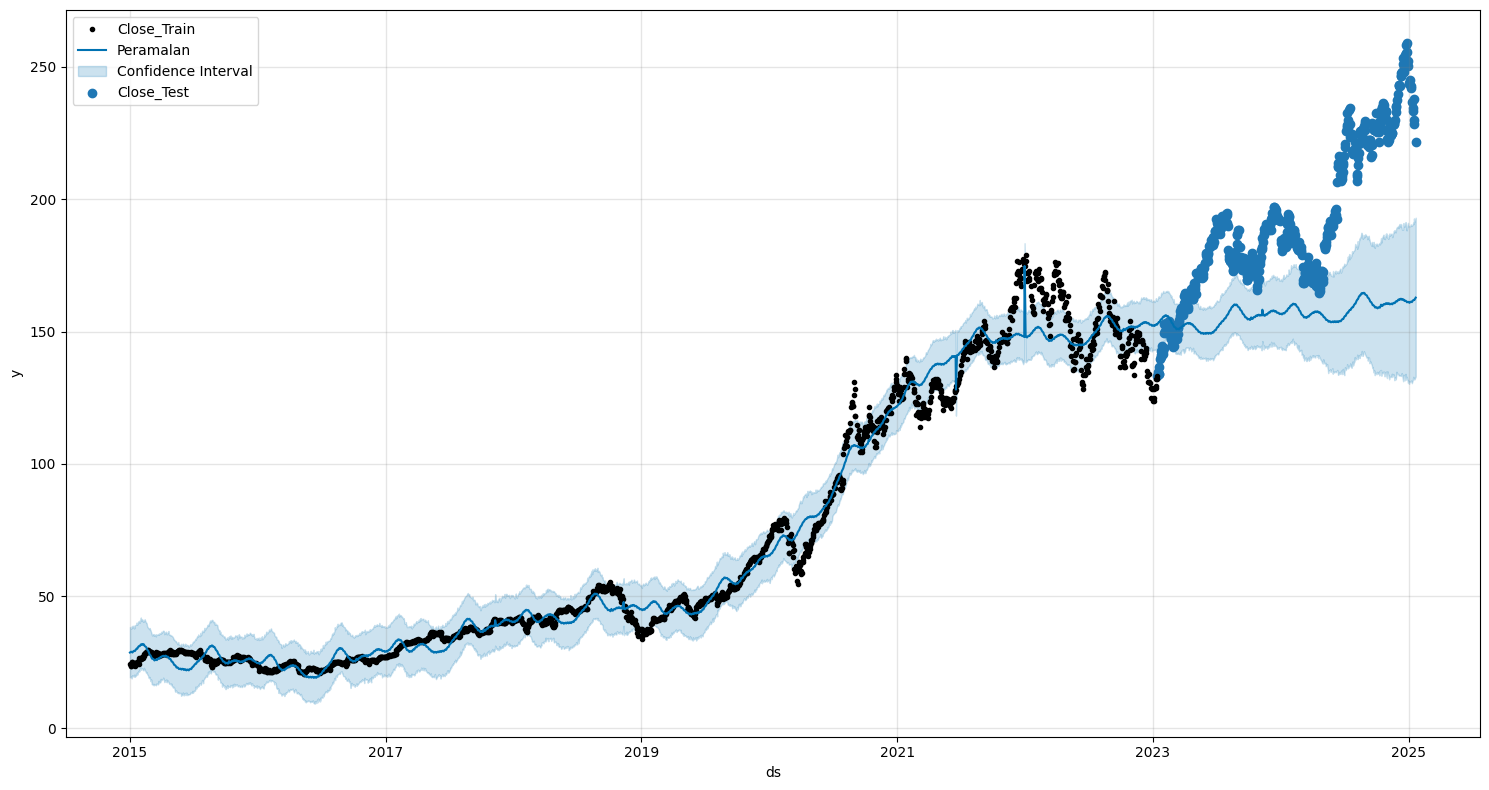

In [259]:
train_dates = pd.DataFrame({'ds': aapl_close_train.index})
test_dates = pd.DataFrame({'ds': aapl_close_test.index})
future_dates = pd.concat([train_dates, test_dates]).drop_duplicates().sort_values(by='ds')
future_dates['ds'] = pd.to_datetime(future_dates['ds'])
forecast = model_close.predict(future_dates)
model_close.plot(forecast, uncertainty=True, figsize=(15,8))
plt.scatter(aapl_stock[split_date:].index, aapl_stock['Close'][split_date:])
plt.legend(['Close_Train', 'Peramalan', 'Confidence Interval', 'Close_Test'], loc='upper left')

In [265]:
print(f"{len(aapl_close_test)}, {len(forecast['yhat'][forecast['ds'] >= split_date])}")

506, 506


In [267]:
rmse = root_mean_squared_error(aapl_close_test['Close'], forecast['yhat'][forecast['ds'] >= split_date])
mae = mean_absolute_error(aapl_close_test['Close'], forecast['yhat'][forecast['ds'] >= split_date])
mape = mean_absolute_percentage_error(aapl_close_test['Close'], forecast['yhat'][forecast['ds'] >= split_date])

print(f"RMSE : {rmse} | MAE : {mae}, | MAPE : {mape}")

RMSE : 42.985743595111735 | MAE : 35.8128540881658, | MAPE : 0.174141694659016


## Sequencial DL Model

### RNN

### LSTM

# Result & Evaluation

Traditional ML (Random Forest) outperform Prophet

In [150]:
# Can Use MLflow